In [ ]:
#kaggle.com/datasets/shivamb/netflix-shows
# This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.
import numpy as np 
import pandas as pd
data = pd.read_csv("netflix_titles.csv")
data.set_index("show_id", inplace=True)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
print("размер данных", data.shape)
print("голова")
print(data.head())


размер данных (8807, 11)
голова
            type                  title         director  \
show_id                                                    
s1         Movie   Dick Johnson Is Dead  Kirsten Johnson   
s2       TV Show          Blood & Water              NaN   
s3       TV Show              Ganglands  Julien Leclercq   
s4       TV Show  Jailbirds New Orleans              NaN   
s5       TV Show           Kota Factory              NaN   

                                                                                                                                                                                                                                                                                                                    cast  \
show_id                                                                                                                                                                                                                                

In [4]:
print("хвост")
print(data.tail())


хвост
            type        title         director  \
show_id                                          
s8803      Movie       Zodiac    David Fincher   
s8804    TV Show  Zombie Dumb              NaN   
s8805      Movie   Zombieland  Ruben Fleischer   
s8806      Movie         Zoom     Peter Hewitt   
s8807      Movie       Zubaan      Mozez Singh   

                                                                                                                                                                cast  \
show_id                                                                                                                                                                
s8803    Mark Ruffalo, Jake Gyllenhaal, Robert Downey Jr., Anthony Edwards, Brian Cox, Elias Koteas, Donal Logue, John Carroll Lynch, Dermot Mulroney, Chloë Sevigny   
s8804                                                                                                                                      

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8807 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   director      6173 non-null   object
 3   cast          7982 non-null   object
 4   country       7976 non-null   object
 5   date_added    8797 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 825.7+ KB
None


In [6]:
print(data.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [7]:
print(data.describe(include="object"))

         type                 title       director                cast  \
count    8807                  8807           6173                7982   
unique      2                  8807           4528                7692   
top     Movie  Dick Johnson Is Dead  Rajiv Chilaka  David Attenborough   
freq     6131                     1             19                  19   

              country       date_added rating  duration  \
count            7976             8797   8803      8804   
unique            748             1767     17       220   
top     United States  January 1, 2020  TV-MA  1 Season   
freq             2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dramas, International Movies   
freq                             362   

                                                                                                                                    

In [8]:
print("колличесво пропусков \n", data.isnull().sum())
print("повторяшки :", data.duplicated().sum())

колличесво пропусков 
 type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
повторяшки : 0


In [9]:
#у каждого режисёра свой подход, поэтому дав информацию по любому из режисёров можно сильно ввести в заблуждение пользователя
#у фильмов по прежнему нет режисера и заполнять их всех одним "unknown director" испортит данные
missing_indices = data[data["director"].isnull()].index
for i, index in enumerate(missing_indices):
    data.at[index, "director"] = f"Unknow Director {i}"
#аналогично режисёрам
data["cast"] = data["cast"].fillna("Unknown_cast")
missing_indices = data[data["cast"].isnull()].index
for i, index in enumerate(missing_indices):
    data.at[index, "cast"] = f"Unknow cast {i}"
#у единственного числового прищнака нет пропусков, даже если бы были пропуски, медиана и среднее бы выдало примерно один и тот же ответ, если все данные корректны
data["release_year"] = data["release_year"].fillna(data["release_year"].median())
data["release_year"] = data["release_year"].fillna(data["release_year"].mean())
#скорее всего фильм был снят там же где и большенство фильмов
data["country"] = data["country"].fillna(data["country"].mode()[0])
#это очень мало фильмов, не испортит статистику
data.dropna(subset=["duration", "rating", "date_added"], inplace=True)

In [10]:
print("колличество пропусков \n", data.isnull().sum())

колличество пропусков 
 type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [11]:
import scipy.stats as stats
osnov_stats = data["release_year"].agg(["min", "max", "mean", "median"])
mode_val = data["release_year"].mode()[0]
percent = data["release_year"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
varience = data["release_year"].var()
skewness = data["release_year"].skew()
kurtosis = data["release_year"].kurtosis()
print(osnov_stats)
print("мода", mode_val)
print("парцентили \n", percent)
print("дисперсия", f"{varience:.4f}")
print("ассиметрия", f"{skewness:.4f}")
print("Эксцесс", f"{kurtosis:.4f}")
#высокая дисперсия показывает что много фильмов в широком диапозоне
#отрицательная ассиметрия показывает что новых фильмов сильно больше чем старых
#высокий эксцесс показывает что большенство фильмов сосредоточено в коротком промежутке выхода

min       1925.000000
max       2021.000000
mean      2014.183163
median    2017.000000
Name: release_year, dtype: float64
мода 2018
парцентили 
 0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64
дисперсия 77.8889
ассиметрия -3.4465
Эксцесс 16.2198


In [12]:
print(data.head())


            type                  title           director  \
show_id                                                      
s1         Movie   Dick Johnson Is Dead    Kirsten Johnson   
s2       TV Show          Blood & Water  Unknow Director 0   
s3       TV Show              Ganglands    Julien Leclercq   
s4       TV Show  Jailbirds New Orleans  Unknow Director 1   
s5       TV Show           Kota Factory  Unknow Director 2   

                                                                                                                                                                                                                                                                                                                    cast  \
show_id                                                                                                                                                                                                                                                  

In [13]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      8790 non-null   object
 3   cast          8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 1.1+ MB
None


In [14]:
data["date_added"] = pd.to_datetime(data["date_added"].str.strip())
data["month_added"] = data["date_added"].dt.month
data["year_added"] = data["date_added"].dt.year
data = pd.get_dummies(data, columns=["type", "country"], prefix="" , drop_first=False)

In [15]:
rating_map = {
    'TV-Y': 0,        # Для всех детей
    'TV-G': 0,        # Общая аудитория
    'G': 0,           # Общая аудитория
    'TV-Y7': 7,       # Дети 7+
    'TV-Y7-FV': 7,    # Дети 7+ (с элементами фэнтези-насилия)
    'PG': 8,          # Рекомендуется присмотр родителей
    'TV-PG': 10,      # Рекомендуется присмотр родителей
    'PG-13': 13,      # Родителям рекомендуется быть осторожными (13+)
    'TV-14': 14,      # Не рекомендуется детям до 14 лет
    'R': 17,          # Ограничено: лицам до 17 лет нужен сопровождающий
    'TV-MA': 17,      # Только для взрослых (17+)
    'NC-17': 18,      # Только для взрослых (18+)
    'NR': 16,         # Not Rated (приравниваем к подростковому)
    'UR': 16          # Unrated (приравниваем к подростковому)
}
data["min_age"] = data["rating"].map(rating_map)

In [16]:
print(data.head())


                         title           director  \
show_id                                             
s1        Dick Johnson Is Dead    Kirsten Johnson   
s2               Blood & Water  Unknow Director 0   
s3                   Ganglands    Julien Leclercq   
s4       Jailbirds New Orleans  Unknow Director 1   
s5                Kota Factory  Unknow Director 2   

                                                                                                                                                                                                                                                                                                                    cast  \
show_id                                                                                                                                                                                                                                                                                                                 

In [17]:
print(data.info())
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, s1 to s8807
Columns: 762 entries, title to min_age
dtypes: bool(750), datetime64[ns](1), int32(2), int64(2), object(7)
memory usage: 7.3+ MB
None
Index(['title', 'director', 'cast', 'date_added', 'release_year', 'rating',
       'duration', 'listed_in', 'description', 'month_added',
       ...
       '_Uruguay, Argentina, Spain', '_Uruguay, Germany',
       '_Uruguay, Guatemala', '_Uruguay, Spain, Mexico', '_Venezuela',
       '_Venezuela, Colombia', '_Vietnam', '_West Germany', '_Zimbabwe',
       'min_age'],
      dtype='object', length=762)


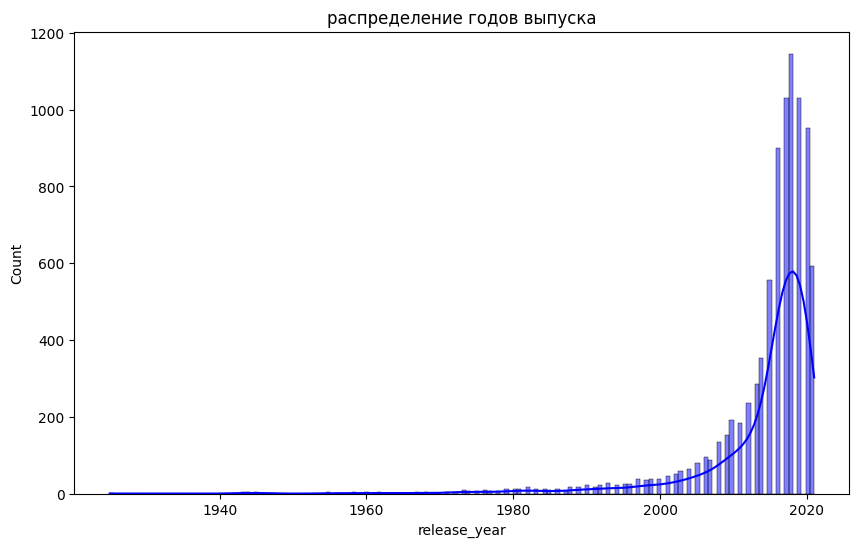

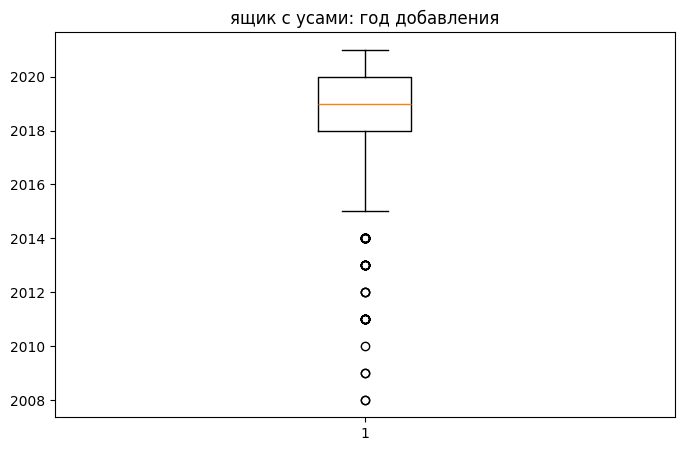

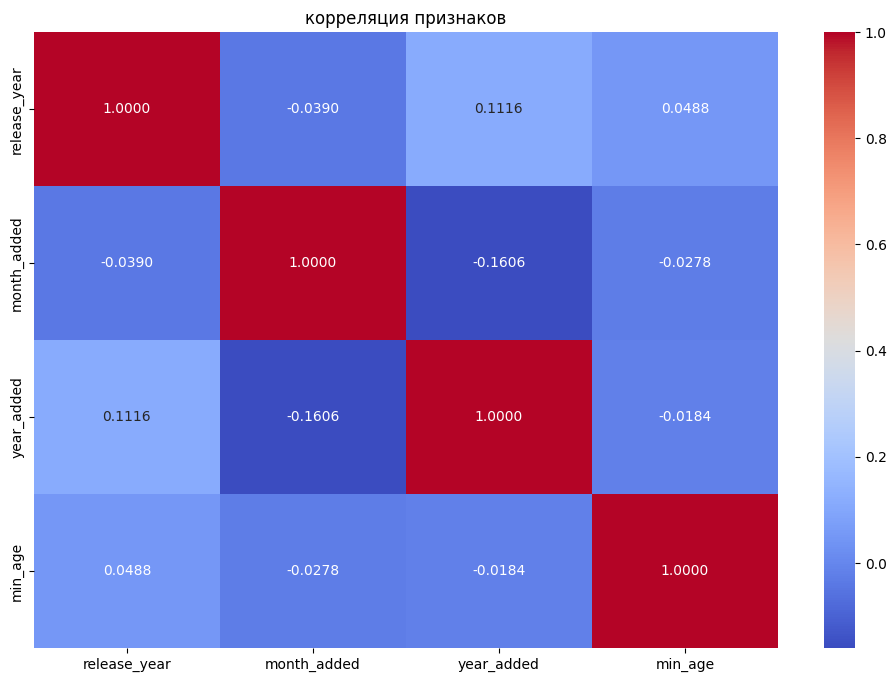

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.figure(figsize=(10, 6))
sns.histplot(data["release_year"], kde=True, color="Blue")
plt.title("распределение годов выпуска")


plt.figure(figsize=(8, 5))
plt.boxplot(data["year_added"])
plt.title("ящик с усами: год добавления")
plt.show()


fig = px.pie(data, names="_TV Show", title="соотношение 0 = Movie, 1 = TV Show", hole=0.4, color_discrete_sequence=['#e50914', '#221f1f'])
fig.show()


plt.figure(figsize=(12, 8))
numeric_cals = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_cals.corr(), annot=True, cmap="coolwarm", fmt=".4f")
plt.title("корреляция признаков")
plt.show()

## 1.большая часть контента - фильмы
## 2.половина контента вышла после 2017
## 3.больше всего контента было добавлено в промежутке с 2018 по 2020 года
## 4.в трети контента не указан режисёр
## 5.дата релиза и дата добавления в сервис слабо коррелируют
## 6.в трети контента не указан каст актёров
## 7.разница между самым свежим релизом и самым старым 96 лет

Дисбаланс типов контента (Movie vs TV Show):

    Наблюдение: В датасете наблюдается значительное преобладание фильмов (Movies) над сериалами (TV Shows) (по данным describe, Movie встречается 6131 раз, в то время как сериалов в разы меньше).

    Гипотеза: Поскольку целевая переменная (тип контента) сильно несбалансирована, модели машинного обучения могут показывать высокую точность на «фильмах», но систематически ошибаться при прогнозировании сериалов. Для улучшения качества предсказаний необходимо применить методы борьбы с дисбалансом (например, SMOTE или взвешивание классов).

Влияние категории release_year на распределение:

    Наблюдение: Статистические показатели (отрицательная ассиметрия -3.4465 и высокий эксцесс 16.2198) указывают на то, что большинство контента на платформе — относительно «свежее» (выпущено за последние годы).

    Гипотеза: Год выпуска контента является сильным предиктором для определения его типа. Вероятно, более современные данные с большей вероятностью будут классифицироваться как «TV Shows», так как Netflix активно наращивал долю сериального контента в последние годы.

Природа пропусков в данных:

    Наблюдение: Пропуски в таких признаках, как director и cast, распределены неравномерно. Многие сериалы не имеют режиссера в явном виде (NaN), так как над ними часто работают несколько режиссеров эпизодов.

    Гипотеза: Пропуски в признаке director сами по себе являются информативным признаком, коррелирующим с целевой переменной type. Значение NaN в поле director с высокой вероятностью указывает на то, что перед нами сериал, а не фильм.

## Использование ИИ

## ИИ использовал чтобы разобраться с plotly и для гипотез в конце